- Entraînement Modèles F1 - Prédiction du Gagnant


In [38]:
# === Imports de base ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

# === Machine Learning ===
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb

# Configuration des warnings
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


- Chargement des Données

In [39]:
# Charger les données
df = pd.read_excel("../data/raw/f1_cleaned.xlsx")

#? df: DataFrame contenant toutes les courses F1 de 2000 à 2025

print("=== Données chargées ===")
print(f"Nombre total de courses: {len(df)}")
print(f"Nombre de colonnes: {len(df.columns)}")
print(f"Période couverte: {df['Season'].min()} - {df['Season'].max()}")

# Afficher les premières lignes
df.head()

=== Données chargées ===
Nombre total de courses: 10398
Nombre de colonnes: 20
Période couverte: 2000 - 2025


,Season,Round,Rain,CircuitID,country,ConstructorName,constructorId,ConstructorNationality,DriverID,DriverName,DriverNationality,Position,Points,Grid,Status,Full Name,PositionChange,Podium,DNF,Winner
0,2000,1,0,albert_park,Australia,Arrows,arrows,British,rosa,pedro,Spanish,20,0.0,12,Suspension,PEDRO ROSA,-8,No,Yes,0
1,2000,1,0,albert_park,Australia,Arrows,arrows,British,verstappen,jos,Dutch,18,0.0,13,Suspension,JOS VERSTAPPEN,-5,No,Yes,0
2,2000,1,0,albert_park,Australia,BAR,bar,British,villeneuve,jacques,Canadian,4,3.0,8,Finished,JACQUES VILLENEUVE,4,No,No,0
3,2000,1,0,albert_park,Australia,BAR,bar,British,zonta,ricardo,Brazilian,6,1.0,16,Finished,RICARDO ZONTA,10,No,No,0
4,2000,1,0,albert_park,Australia,Benetton,benetton,Italian,fisichella,giancarlo,Italian,5,2.0,9,Finished,GIANCARLO FISICHELLA,4,No,No,0


- Exploration des Données

In [40]:
# Voir les colonnes disponibles
print("Colonnes disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

# Informations sur les données
print("\nInformations:")
print(f"Nombre de pilotes: {df['DriverID'].nunique()}")
print(f"Nombre d'écuries: {df['ConstructorName'].nunique()}")
print(f"Nombre de circuits: {df['CircuitID'].nunique()}")
print(f"Nombre de victoires: {df['Winner'].sum()}")

Colonnes disponibles:
 1. Season
 2. Round
 3. Rain
 4. CircuitID
 5. country
 6. ConstructorName
 7. constructorId
 8. ConstructorNationality
 9. DriverID
10. DriverName
11. DriverNationality
12. Position
13. Points
14. Grid
15. Status
16. Full Name
17. PositionChange
18. Podium
19. DNF
20. Winner

Informations:
Nombre de pilotes: 129
Nombre d'écuries: 38
Nombre de circuits: 38
Nombre de victoires: 495


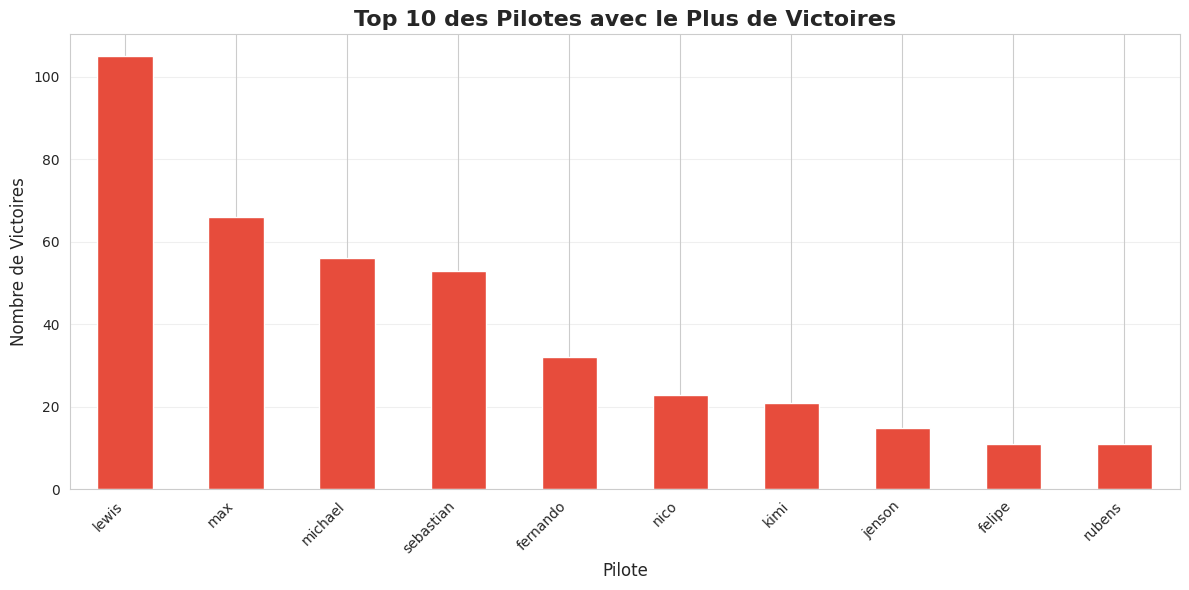


Top 3:
1. lewis: 105 victoires
2. max: 66 victoires
3. michael: 56 victoires


In [41]:
# Visualiser les 10 pilotes avec le plus de victoires
winners = df[df['Winner'] == 1].groupby('DriverName').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
winners.plot(kind='bar', color='#E74C3C')
plt.title('Top 10 des Pilotes avec le Plus de Victoires', fontsize=16, fontweight='bold')
plt.xlabel('Pilote', fontsize=12)
plt.ylabel('Nombre de Victoires', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 3:")
for i, (pilote, victoires) in enumerate(winners.head(3).items(), 1):
    print(f"{i}. {pilote}: {victoires} victoires")

- Préparation des Données (Preprocessing)

In [42]:
# Sélectionner les colonnes importantes
colonnes_importantes = [
    'Season',           # Année de la course
    'Round',            # Numéro de la course dans la saison
    'Grid',             # Position de départ (qualification)
    'Rain',             # Pluie ou pas (0 = sec, 1 = pluie)
    'DriverID',         # Identifiant du pilote
    'ConstructorName',  # Nom de l'écurie
    'CircuitID',        # Identifiant du circuit
    'Winner'            # Target: 1 = a gagné, 0 = pas gagné
]

df_clean = df[colonnes_importantes].copy()

#? copy(): Crée une copie pour ne pas modifier le DataFrame original

print("Colonnes sélectionnées")
print(f"Nombre de colonnes gardées: {len(colonnes_importantes)}")
df_clean.head()

Colonnes sélectionnées
Nombre de colonnes gardées: 8


,Season,Round,Grid,Rain,DriverID,ConstructorName,CircuitID,Winner
0,2000,1,12,0,rosa,Arrows,albert_park,0
1,2000,1,13,0,verstappen,Arrows,albert_park,0
2,2000,1,8,0,villeneuve,BAR,albert_park,0
3,2000,1,16,0,zonta,BAR,albert_park,0
4,2000,1,9,0,fisichella,Benetton,albert_park,0


In [43]:
# Convertir les catégories (texte) en nombres
print("Conversion des catégories en nombres...")

df_clean['DriverID_code'] = df_clean['DriverID'].astype('category').cat.codes
df_clean['ConstructorName_code'] = df_clean['ConstructorName'].astype('category').cat.codes
df_clean['CircuitID_code'] = df_clean['CircuitID'].astype('category').cat.codes

#? astype('category').cat.codes: Convertit chaque texte unique en un nombre
#? Exemple: 'max' → 89, 'lewis' → 56, 'charles' → 23, etc.

print("Conversion terminée")
print("\nExemple:")
print(df_clean[['DriverID', 'DriverID_code']].head(10))

Conversion des catégories en nombres...
Conversion terminée

Exemple:
             DriverID  DriverID_code
0                rosa            101
1          verstappen            118
2          villeneuve            120
3               zonta            128
4          fisichella             34
5                wurz            124
6         barrichello              9
7  michael_schumacher             79
8             herbert             50
9              irvine             53


- Préparation de X (features) et y (target)

In [44]:
# X = Features (ce qu'on utilise pour prédire)
X = df_clean[[
    'Grid',                    # Position de départ
    'Rain',                    # Météo
    'Round',                   # Numéro de la course
    'Season',                  # Année
    'DriverID_code',           # Pilote (encodé)
    'ConstructorName_code',    # Écurie (encodée)
    'CircuitID_code'           # Circuit (encodé)
]]

# y = Target (ce qu'on veut prédire)
y = df_clean['Winner']

#? X: Les "informations" qu'on donne au modèle pour faire une prédiction
#? y: La "réponse" correcte (gagné ou pas gagné)

print("=== Préparation X et y ===")
print(f"\nX (Features):")
print(f"  - Forme: {X.shape}")
print(f"  - Nombre de lignes: {X.shape[0]}")
print(f"  - Nombre de colonnes: {X.shape[1]}")

print(f"\ny (Target):")
print(f"  - Forme: {y.shape}")
print(f"  - Nombre de victoires (1): {y.sum()}")
print(f"  - Nombre de non-victoires (0): {len(y) - y.sum()}")
print(f"  - Pourcentage de victoires: {y.sum()/len(y)*100:.2f}%")

=== Préparation X et y ===

X (Features):
  - Forme: (10398, 7)
  - Nombre de lignes: 10398
  - Nombre de colonnes: 7

y (Target):
  - Forme: (10398,)
  - Nombre de victoires (1): 495
  - Nombre de non-victoires (0): 9903
  - Pourcentage de victoires: 4.76%


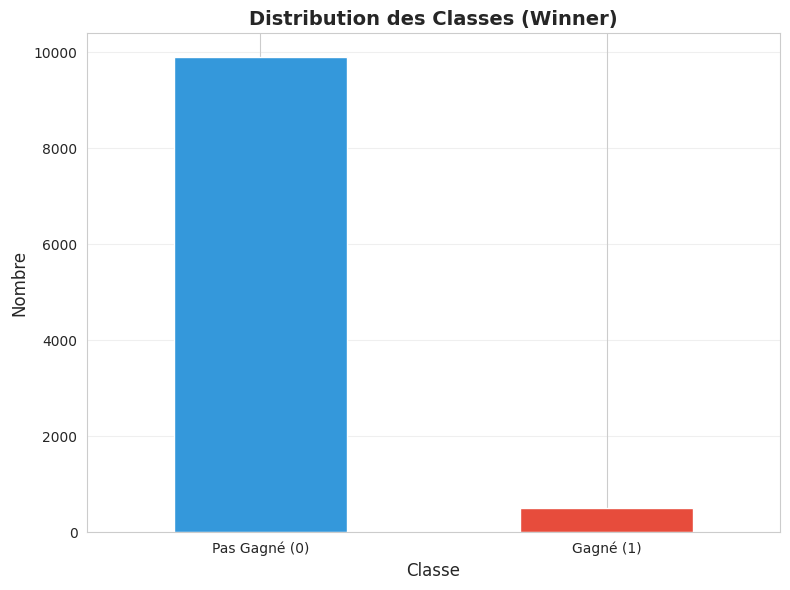

Les données sont déséquilibrées (beaucoup plus de 0 que de 1)
C'est normal: il y a 1 seul gagnant par course !


In [45]:
# Visualiser l'équilibre des classes
plt.figure(figsize=(8, 6))
y.value_counts().plot(kind='bar', color=['#3498DB', '#E74C3C'])
plt.title('Distribution des Classes (Winner)', fontsize=14, fontweight='bold')
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Nombre', fontsize=12)
plt.xticks([0, 1], ['Pas Gagné (0)', 'Gagné (1)'], rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Les données sont déséquilibrées (beaucoup plus de 0 que de 1)")
print("C'est normal: il y a 1 seul gagnant par course !")

- Séparation Train / Test (80% / 20%)

In [46]:
# Séparer les données en 2 parties:
# - Train (80%): Pour entraîner le modèle
# - Test (20%): Pour tester le modèle sur des données qu'il n'a jamais vues

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% pour le test
    random_state=42,    # Pour avoir toujours le même résultat
    stratify=y          # Garde la même proportion de 0 et 1 dans train et test
)

#? train_test_split: Mélange et sépare automatiquement les données
#? stratify=y: Important! Assure qu'on a le même ratio de gagnants dans train et test

print("=== Séparation Train / Test ===")
print(f"\nTrain:")
print(f"  - X_train: {X_train.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - Victoires: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.2f}%)")

print(f"\nTest:")
print(f"  - X_test: {X_test.shape}")
print(f"  - y_test: {y_test.shape}")
print(f"  - Victoires: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")


=== Séparation Train / Test ===

Train:
  - X_train: (8318, 7)
  - y_train: (8318,)
  - Victoires: 396 (4.76%)

Test:
  - X_test: (2080, 7)
  - y_test: (2080,)
  - Victoires: 99 (4.76%)


- Entraînement des Modèles

- Modèle 1: Random Forest 

In [47]:
print("=== RANDOM FOREST ===")

# Créer le modèle
rf_model = RandomForestClassifier(
    n_estimators=100,     # Nombre d'arbres dans la forêt
    max_depth=10,         # Profondeur maximum de chaque arbre
    random_state=42,      # Pour avoir toujours le même résultat
    n_jobs=-1             # Utiliser tous les CPU disponibles
)

#? RandomForest: Crée une "forêt" de 100 arbres de décision
#? Chaque arbre vote pour une prédiction, et la majorité gagne

# Entraîner
rf_model.fit(X_train, y_train)

#? fit(): Le modèle apprend les patterns dans les données d'entraînement

print("Entraînement terminé !")

# Prédire sur le test
rf_predictions = rf_model.predict(X_test)

#? predict(): Le modèle fait des prédictions sur les données de test

# Calculer la précision
rf_accuracy = accuracy_score(y_test, rf_predictions)

#? accuracy_score: Compare les prédictions avec les vraies réponses

print(f"\nPrécision sur le test: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

=== RANDOM FOREST ===
Entraînement terminé !

Précision sur le test: 0.9572 (95.72%)


- Modèle 2: XGBoost 

In [48]:
print("=== XGBOOST ===")

# Créer le modèle
xgb_model = xgb.XGBClassifier(
    n_estimators=100,      # Nombre d'arbres
    max_depth=6,           # Profondeur des arbres
    learning_rate=0.1,     # Vitesse d'apprentissage
    random_state=42
)

#? XGBoost: Un algorithme très puissant qui crée des arbres de manière séquentielle
#? Chaque nouvel arbre corrige les erreurs du précédent

# Entraîner
xgb_model.fit(X_train, y_train)


# Prédire
xgb_predictions = xgb_model.predict(X_test)

# Calculer la précision
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print(f"\nPrécision sur le test: {xgb_accuracy:.4f} ({xgb_accuracy*100:.2f}%)")

=== XGBOOST ===



Précision sur le test: 0.9553 (95.53%)


- Comparaison des Modèles

=== COMPARAISON DES MODÈLES ===
       Modèle  Précision  Précision %
Random Forest   0.957212    95.721154
      XGBoost   0.955288    95.528846


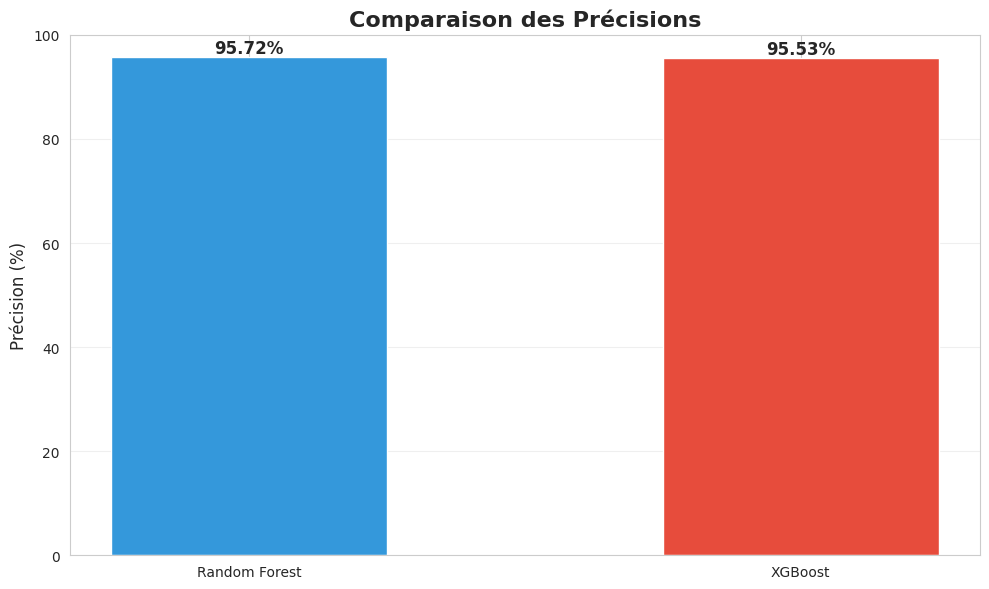


 Meilleur modèle: Random Forest
Précision: 95.72%


In [49]:
# Comparer les résultats
resultats = pd.DataFrame({
    'Modèle': ['Random Forest', 'XGBoost'],
    'Précision': [rf_accuracy, xgb_accuracy]
})

resultats['Précision %'] = resultats['Précision'] * 100

print("=== COMPARAISON DES MODÈLES ===")
print(resultats.to_string(index=False))

# Visualiser
plt.figure(figsize=(10, 6))
bars = plt.bar(resultats['Modèle'], resultats['Précision %'], 
               color=['#3498DB', '#E74C3C'], width=0.5)

plt.title('Comparaison des Précisions', fontsize=16, fontweight='bold')
plt.ylabel('Précision (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Déterminer le meilleur
if xgb_accuracy > rf_accuracy:
    print("\nMeilleur modèle: XGBoost")
    best_model = xgb_model
    best_name = "XGBoost"
    best_accuracy = xgb_accuracy
else:
    print("\n Meilleur modèle: Random Forest")
    best_model = rf_model
    best_name = "Random Forest"
    best_accuracy = rf_accuracy

print(f"Précision: {best_accuracy*100:.2f}%")

- Matrice de Confusion (Meilleur Modèle)

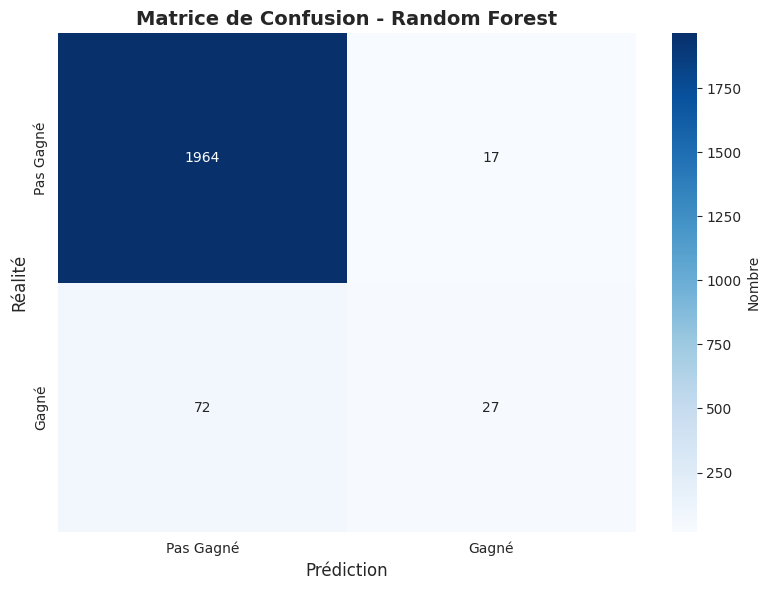


=== Interprétation ===
✅ Vrai Négatif (en haut à gauche): 1964 - Correctement prédit 'Pas Gagné'
❌ Faux Positif (en haut à droite): 17 - Prédit 'Gagné' mais c'était 'Pas Gagné'
❌ Faux Négatif (en bas à gauche): 72 - Prédit 'Pas Gagné' mais c'était 'Gagné'
✅ Vrai Positif (en bas à droite): 27 - Correctement prédit 'Gagné'


In [50]:
# Prédictions du meilleur modèle
best_predictions = best_model.predict(X_test)

# Calculer la matrice de confusion
cm = confusion_matrix(y_test, best_predictions)

#? Matrice de confusion: Montre combien de prédictions sont correctes/incorrectes
#? [Vrai Négatif,  Faux Positif]
#? [Faux Négatif,  Vrai Positif]

# Visualiser
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['Pas Gagné', 'Gagné'],
           yticklabels=['Pas Gagné', 'Gagné'],
           cbar_kws={'label': 'Nombre'})

plt.title(f'Matrice de Confusion - {best_name}', fontsize=14, fontweight='bold')
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Réalité', fontsize=12)
plt.tight_layout()
plt.show()

print("\n=== Interprétation ===")
print(f"✅ Vrai Négatif (en haut à gauche): {cm[0,0]} - Correctement prédit 'Pas Gagné'")
print(f"❌ Faux Positif (en haut à droite): {cm[0,1]} - Prédit 'Gagné' mais c'était 'Pas Gagné'")
print(f"❌ Faux Négatif (en bas à gauche): {cm[1,0]} - Prédit 'Pas Gagné' mais c'était 'Gagné'")
print(f"✅ Vrai Positif (en bas à droite): {cm[1,1]} - Correctement prédit 'Gagné'")

- Rapport de Classification Détaillé

In [51]:
# Rapport détaillé
print(f"=== RAPPORT DE CLASSIFICATION - {best_name} ===")
print()
print(classification_report(y_test, best_predictions, 
                          target_names=['Pas Gagné', 'Gagné']))

print("\n=== Explication des Métriques ===")
print("\nPrécision (Precision):")
print("   Quand le modèle prédit 'Gagné', à quelle fréquence il a raison?")
print("   Plus c'est élevé, mieux c'est (max = 1.00)")

print("\nRappel (Recall):")
print("   Sur tous les vrais gagnants, combien le modèle en trouve?")
print("   Plus c'est élevé, mieux c'est (max = 1.00)")

print("\nF1-Score:")
print("   Moyenne harmonique entre Précision et Rappel")
print("   Plus c'est élevé, mieux c'est (max = 1.00)")

print("\nAccuracy:")
print("   Pourcentage de prédictions correctes au total")
print(f"   Notre modèle: {best_accuracy*100:.2f}%")

=== RAPPORT DE CLASSIFICATION - Random Forest ===

              precision    recall  f1-score   support

   Pas Gagné       0.96      0.99      0.98      1981
       Gagné       0.61      0.27      0.38        99

    accuracy                           0.96      2080
   macro avg       0.79      0.63      0.68      2080
weighted avg       0.95      0.96      0.95      2080


=== Explication des Métriques ===

Précision (Precision):
   Quand le modèle prédit 'Gagné', à quelle fréquence il a raison?
   Plus c'est élevé, mieux c'est (max = 1.00)

Rappel (Recall):
   Sur tous les vrais gagnants, combien le modèle en trouve?
   Plus c'est élevé, mieux c'est (max = 1.00)

F1-Score:
   Moyenne harmonique entre Précision et Rappel
   Plus c'est élevé, mieux c'est (max = 1.00)

Accuracy:
   Pourcentage de prédictions correctes au total
   Notre modèle: 95.72%


- Importance des Features

=== IMPORTANCE DES FEATURES ===
             Feature  Importance
                Grid    0.456826
              Season    0.125398
       DriverID_code    0.115472
      CircuitID_code    0.093836
               Round    0.092595
ConstructorName_code    0.090696
                Rain    0.025176


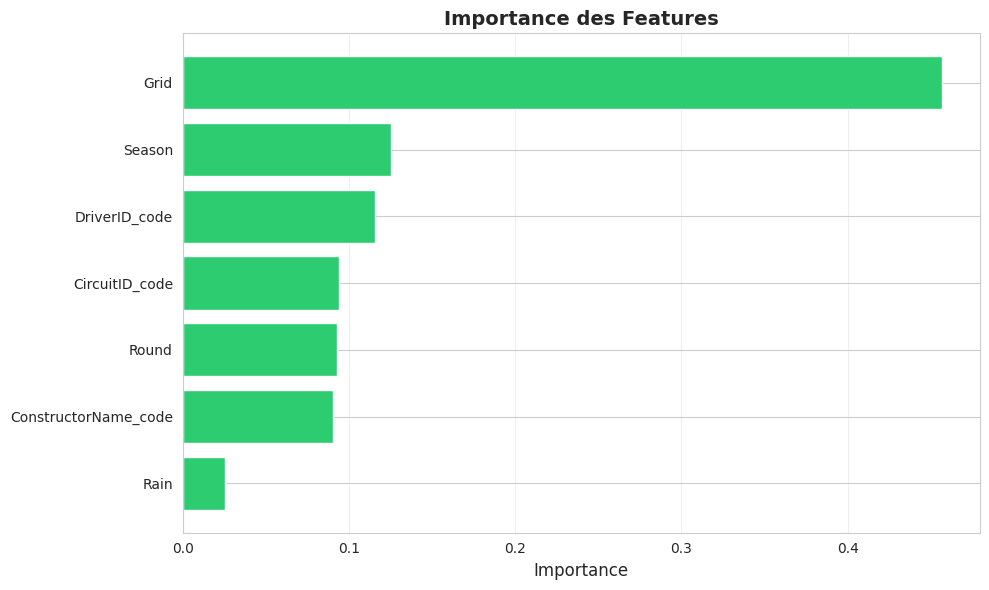


Interprétation:
   La feature la plus importante est: Grid
   Cela signifie que cette variable influence le plus la prédiction du gagnant.


In [52]:
# Obtenir l'importance des features
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X.columns
    
    # Créer un DataFrame
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("=== IMPORTANCE DES FEATURES ===")
    print(importance_df.to_string(index=False))
    
    #? Feature Importance: Montre quelle variable est la plus importante pour la prédiction
    #? Plus le score est élevé, plus la variable est importante
    
    # Visualiser
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='#2ECC71')
    plt.xlabel('Importance', fontsize=12)
    plt.title('Importance des Features', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nInterprétation:")
    print(f"   La feature la plus importante est: {importance_df.iloc[0]['Feature']}")
    print("   Cela signifie que cette variable influence le plus la prédiction du gagnant.")
else:
    print("Ce modèle ne fournit pas d'importance des features")

- Sauvegarde du Modèle

In [53]:
# Créer le dossier si n'existe pas
Path("../models").mkdir(parents=True, exist_ok=True)

# Sauvegarder le meilleur modèle
model_path = "../models/f1_winner_model.joblib"
joblib.dump(best_model, model_path)

#? joblib.dump: Sauvegarde le modèle pour pouvoir l'utiliser plus tard

print("=== SAUVEGARDE DU MODÈLE ===")
print(f"\nModèle sauvegardé: {model_path}")
print(f"Type: {best_name}")
print(f"Précision: {best_accuracy*100:.2f}%")

# Sauvegarder aussi les informations
info = {
    'model_name': best_name,
    'accuracy': float(best_accuracy),
    'features': list(X.columns),
    'n_train': len(X_train),
    'n_test': len(X_test)
}

import json
with open('../models/model_info.json', 'w') as f:
    json.dump(info, f, indent=2)

print("Informations sauvegardées: ../models/model_info.json")

=== SAUVEGARDE DU MODÈLE ===

Modèle sauvegardé: ../models/f1_winner_model.joblib
Type: Random Forest
Précision: 95.72%
Informations sauvegardées: ../models/model_info.json


- Résumé Final

In [55]:
print("="*60)
print("🏎️ RÉSUMÉ DE L'ENTRAÎNEMENT - PRÉDICTION F1")
print("="*60)

print("\nDONNÉES:")
print(f"   • Total: {len(df)} courses")
print(f"   • Période: {df['Season'].min()} - {df['Season'].max()}")
print(f"   • Features utilisées: {X.shape[1]}")

print("\nSÉPARATION:")
print(f"   • Train: {len(X_train)} courses (80%)")
print(f"   • Test: {len(X_test)} courses (20%)")

print("\nMODÈLES TESTÉS:")
print(f"   1. Random Forest: {rf_accuracy*100:.2f}%")
print(f"   2. XGBoost: {xgb_accuracy*100:.2f}%")

print(f"\nMEILLEUR MODÈLE: {best_name}")
print(f"   Précision: {best_accuracy*100:.2f}%")
print(f"   Sauvegardé: models/f1_winner_model.joblib")

print("\nPROCHAINES ÉTAPES:")
print("   1. Utiliser ce modèle pour faire des prédictions")
print("   2. Créer une API avec FastAPI")
print("   3. Intégrer avec Computer Vision")
print("   4. Créer l'interface web")

print("\n" + "="*60)
print("ENTRAÎNEMENT TERMINÉ AVEC SUCCÈS !")
print("="*60)

🏎️ RÉSUMÉ DE L'ENTRAÎNEMENT - PRÉDICTION F1

DONNÉES:
   • Total: 10398 courses
   • Période: 2000 - 2025
   • Features utilisées: 7

SÉPARATION:
   • Train: 8318 courses (80%)
   • Test: 2080 courses (20%)

MODÈLES TESTÉS:
   1. Random Forest: 95.72%
   2. XGBoost: 95.53%

MEILLEUR MODÈLE: Random Forest
   Précision: 95.72%
   Sauvegardé: models/f1_winner_model.joblib

PROCHAINES ÉTAPES:
   1. Utiliser ce modèle pour faire des prédictions
   2. Créer une API avec FastAPI
   3. Intégrer avec Computer Vision
   4. Créer l'interface web

ENTRAÎNEMENT TERMINÉ AVEC SUCCÈS !
